# Lab 06 – Hough Transform, SIFT and Wavelets (8 Tasks)
Tools: **Python, OpenCV, NumPy** (+ PyWavelets for the wavelet task, matplotlib for display).

Images / video are in `Data/` (downloaded from the internet: Wikipedia lab photos, OpenCV samples, Udacity road images). Results are saved in `Output/`.

| # | Task | Method |
|---|---|---|
| 1 | Computer screen detection | Hough Line Transform |
| 2 | Asset tracking in a lab | SIFT |
| 3 | Anomaly detection in sensor data | Wavelet transform |
| 4 | Object recognition (video) | SIFT + homography |
| 5 | Panorama | SIFT + homography stitching |
| 6 | Lane detection | Hough Line Transform |
| 7 | Coins detection and counting | Hough Circle Transform |
| 8 | Smart security system | Background subtraction + contours (boundary detection) |

In [1]:
import cv2, os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs('Output', exist_ok=True)

def read(name, width=None):
    img = cv2.imread('Data/' + name)
    if width:                                   # resize keeping the aspect ratio
        img = cv2.resize(img, (width, int(img.shape[0] * width / img.shape[1])))
    return img

def show(images, titles, save_as=None, cols=None, size=5):
    cols = cols or len(images)
    rows = (len(images) + cols - 1) // cols
    plt.figure(figsize=(size * cols, size * rows * 0.75))
    for i, (img, t) in enumerate(zip(images, titles)):
        plt.subplot(rows, cols, i + 1)
        if img.ndim == 3:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            plt.imshow(img, cmap='gray')
        plt.title(t, fontsize=10); plt.axis('off')
    plt.tight_layout()
    if save_as: plt.savefig('Output/' + save_as, dpi=110)
    plt.show()

sift = cv2.SIFT_create()      # SIFT detector (used in tasks 2, 4, 5)

## Task 1 – Computer screen detection (Hough Line Transform)
Image: a computer lab with a row of monitors (Wikipedia photo, lab_a.jpg).
Steps: Canny edges → **Hough lines** (the straight borders of the screens) → keep horizontal / vertical lines → locate the screens → ON/OFF status → alert if a screen is missing.

lines found: 179 | horizontal (green): 78 | vertical (red): 21


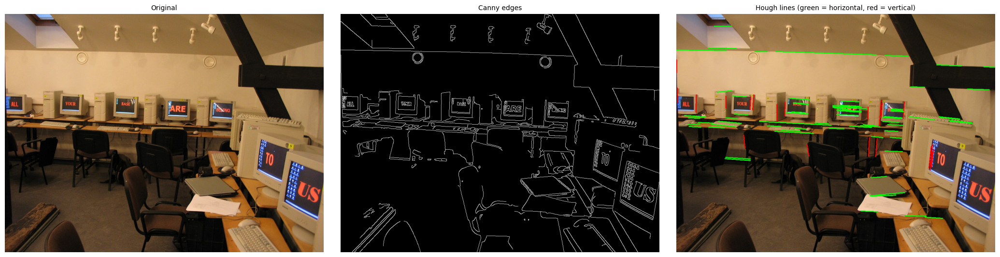

In [2]:
img = read('lab_a.jpg', 1000)
gray = cv2.GaussianBlur(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), (5, 5), 0)
edges = cv2.Canny(gray, 50, 150)

# Probabilistic Hough: returns line segments (x1, y1, x2, y2)
lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi / 180, threshold=50, minLineLength=35, maxLineGap=8).reshape(-1, 4)

line_img = img.copy()
n_h = n_v = 0
for x1, y1, x2, y2 in lines:
    angle = abs(np.degrees(np.arctan2(y2 - y1, x2 - x1)))
    if angle < 8 or angle > 172:                 # horizontal -> top/bottom edge of a screen
        cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 2); n_h += 1
    elif 82 < angle < 98:                        # vertical -> left/right edge of a screen
        cv2.line(line_img, (x1, y1), (x2, y2), (0, 0, 255), 2); n_v += 1
print('lines found:', len(lines), '| horizontal (green):', n_h, '| vertical (red):', n_v)
show([img, edges, line_img], ['Original', 'Canny edges', 'Hough lines (green = horizontal, red = vertical)'], 'task1_lines.png', size=7)

Screens detected ON: 7 | expected: 7
All screens present and ON.

Test image -> screens ON: 5 | expected: 7
ALERT: missing / OFF screens!


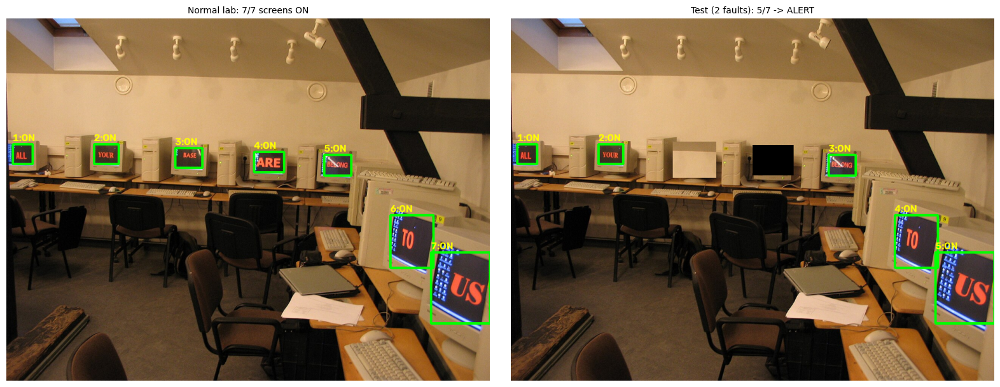

In [3]:
def detect_screens(img):
    # A working screen is a DARK rectangle that contains bright coloured (red) text. Returns list of boxes.
    g = cv2.GaussianBlur(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), (5, 5), 0)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    red = ((hsv[..., 1] > 150) & (hsv[..., 2] > 150) & ((hsv[..., 0] < 12) | (hsv[..., 0] > 165))).astype(np.uint8) * 255
    red = cv2.dilate(red, np.ones((15, 15), np.uint8))                       # screen content
    dark = (g < 70).astype(np.uint8) * 255                                   # dark screen background
    mask = cv2.morphologyEx(dark | red, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((11, 11), np.uint8))   # remove thin connections
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        content = cv2.countNonZero(red[y:y + h, x:x + w]) > 0.1 * w * h          # has screen content (ON)
        mostly_dark = (g[y:y + h, x:x + w] < 90).mean() > 0.55
        if w * h > 1500 and 0.6 < w / h < 2.0 and w < 260 and content and mostly_dark:
            boxes.append((x, y, w, h))
    return sorted(boxes)

def draw_screens(img, boxes):
    out = img.copy()
    for i, (x, y, w, h) in enumerate(boxes, 1):
        cv2.rectangle(out, (x, y), (x + w, y + h), (0, 255, 0), 3)
        cv2.putText(out, f'{i}:ON', (x, y - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    return out

EXPECTED = 7                                    # screens that should be ON in this lab (counted by hand)
boxes = detect_screens(img)
print('Screens detected ON:', len(boxes), '| expected:', EXPECTED)
print('ALERT: missing / OFF screens!' if len(boxes) < EXPECTED else 'All screens present and ON.')

# Test of the anomaly alert: simulate a missing screen (paint over "BASE") and a switched-off screen (paint "ARE" black)
test = img.copy()
test[255:330, 335:425] = img[100:175, 335:425]                 # cover monitor with wall
test[262:325, 500:585] = 0                                      # screen switched off
boxes2 = detect_screens(test)
print(); print('Test image -> screens ON:', len(boxes2), '| expected:', EXPECTED)
print('ALERT: missing / OFF screens!' if len(boxes2) < EXPECTED else 'All screens present and ON.')
show([draw_screens(img, boxes), draw_screens(test, boxes2)], [f'Normal lab: {len(boxes)}/{EXPECTED} screens ON', f'Test (2 faults): {len(boxes2)}/{EXPECTED} -> ALERT'], 'task1_screens.png', size=8)

### Task 1 explanation
* **Hough lines:** Canny edges → `cv2.HoughLinesP` found 179 line segments (78 horizontal, 21 vertical). Horizontal / vertical lines are the top-bottom and left-right borders of the monitors, desks and keyboards, so they show where the screens are.
* **Screens:** a dark rectangle with bright screen content is treated as a working screen. 7 screens are detected and all are **ON** (expected 7).
* **Anomaly test:** one monitor was covered (missing) and one was switched off (black) in a copy of the image → only 5/7 are found and the program prints **ALERT: missing / OFF screens!**
* **Limitations:** the thresholds (dark < 70, red text) are tuned for this photo; in a real lab the camera is fixed, so the expected screen positions can be stored and compared. (I first tried the dark modern lab `lab_b.jpg`, but its monitors are *all off* and blend with the dark desks, so no reliable detection was possible – an example of how lighting changes the result.)

## Task 2 – Asset tracking with SIFT
Two *assets* (reference crops: an iMac with the Apple logo, and a wall-mounted display) are looked up in a **new photo of the lab** taken from a different position (simulated: rotated, smaller and darker). SIFT is scale/rotation invariant, so the assets can still be matched. Matched assets are added to the inventory.

iMac          good matches =  31, RANSAC inliers =  31 -> FOUND
Wall display  good matches =  38, RANSAC inliers =  36 -> FOUND
Inventory: ['iMac', 'Wall display']


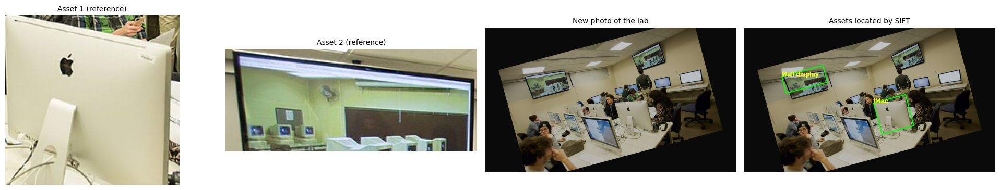

In [4]:
lab = read('lab_d.jpg')
assets = {'iMac': lab[395:600, 660:870], 'Wall display': lab[80:190, 140:410]}

# Second shot of the lab: rotate 15 deg, scale 0.8, lower brightness
h, w = lab.shape[:2]
M = cv2.getRotationMatrix2D((w / 2, h / 2), 15, 0.8)
scene = cv2.warpAffine(lab, M, (w, h))
scene = cv2.convertScaleAbs(scene, alpha=0.8, beta=-10)

def find_asset(ref, scene, ratio=0.7, min_good=10):
    # SIFT keypoints + descriptors
    k1, d1 = sift.detectAndCompute(cv2.cvtColor(ref, cv2.COLOR_BGR2GRAY), None)
    k2, d2 = sift.detectAndCompute(cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY), None)
    # match + Lowe's ratio test (keep match only if clearly better than 2nd best)
    matches = cv2.BFMatcher().knnMatch(d1, d2, k=2)
    good = [m for m, n in matches if m.distance < ratio * n.distance]
    if len(good) < min_good:
        return None, len(good), 0, (k1, k2, good)
    src = np.float32([k1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst = np.float32([k2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, inl = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)    # RANSAC removes wrong matches
    if H is None:
        return None, len(good), 0, (k1, k2, good)
    rh, rw = ref.shape[:2]
    box = cv2.perspectiveTransform(np.float32([[0, 0], [rw, 0], [rw, rh], [0, rh]]).reshape(-1, 1, 2), H)
    return box, len(good), int(inl.sum()), (k1, k2, good)

out, inventory = scene.copy(), []
for name, ref in assets.items():
    box, n_good, n_inl, _ = find_asset(ref, scene)
    print(f'{name:13} good matches = {n_good:3}, RANSAC inliers = {n_inl:3} ->', 'FOUND' if n_inl >= 10 else 'not found')
    if box is not None and n_inl >= 10:
        cv2.polylines(out, [np.int32(box)], True, (0, 255, 0), 4)
        cv2.putText(out, name, tuple(np.int32(box[0, 0])), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 255), 3)
        inventory.append(name)
print('Inventory:', inventory)
show([assets['iMac'], assets['Wall display'], scene, out],
     ['Asset 1 (reference)', 'Asset 2 (reference)', 'New photo of the lab', 'Assets located by SIFT'], 'task2_result.png', cols=4, size=5)

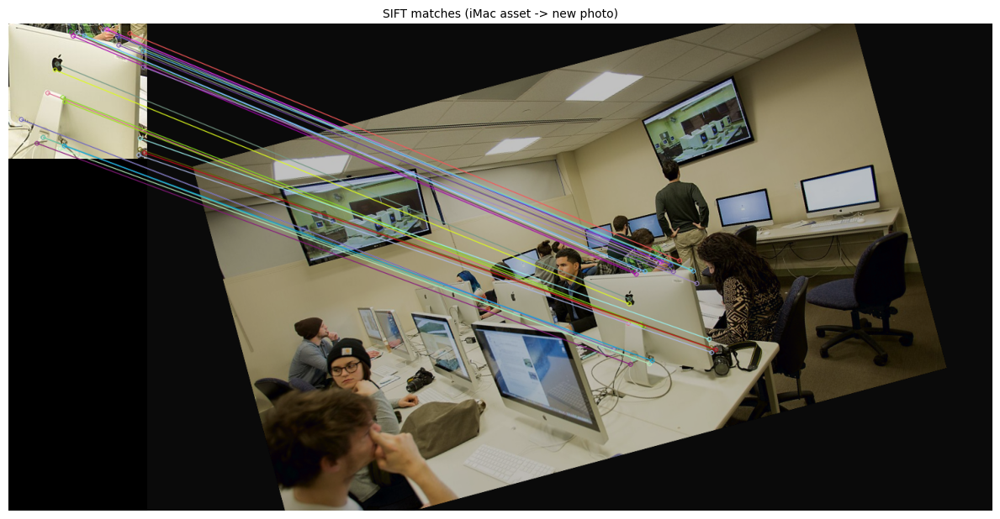

In [5]:
# Show the SIFT matches for the iMac asset
box, n_good, n_inl, (k1, k2, good) = find_asset(assets['iMac'], scene)
vis = cv2.drawMatches(assets['iMac'], k1, scene, k2, good[:40], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
show([vis], ['SIFT matches (iMac asset -> new photo)'], 'task2_matches.png', size=12)

**Result:** both assets were found in a photo that was rotated by 15°, scaled to 80 % and darkened: iMac = 31 inliers, wall display = 36 inliers (RANSAC), so both are added to the inventory.

**Why SIFT works:** SIFT keypoints are invariant to scale and rotation and tolerant to brightness change, so the same asset is matched from a different position. Lowe's ratio test (0.7) removes ambiguous matches and RANSAC removes the remaining wrong ones. A homography gives the bounding box of the asset.
**Limitation:** plain featureless objects (e.g. a black keyboard) have few keypoints and are hard to recognise.

## Task 3 – Anomaly detection in sensor data (Wavelet transform)
Steps: make sample sensor data (slow signal + noise + injected faults) → wavelet decomposition → remove noise by thresholding the detail coefficients → **residual = data − denoised signal** → samples with a big residual are anomalies.

wavelet threshold = 0.578 | residual limit = 0.59
injected faults : [120, 260, 390, 470, 610, 700, 820, 930]
detected        : [120, 260, 390, 470, 610, 700, 820, 930]
found 8/8 injected faults, extra detections: 0


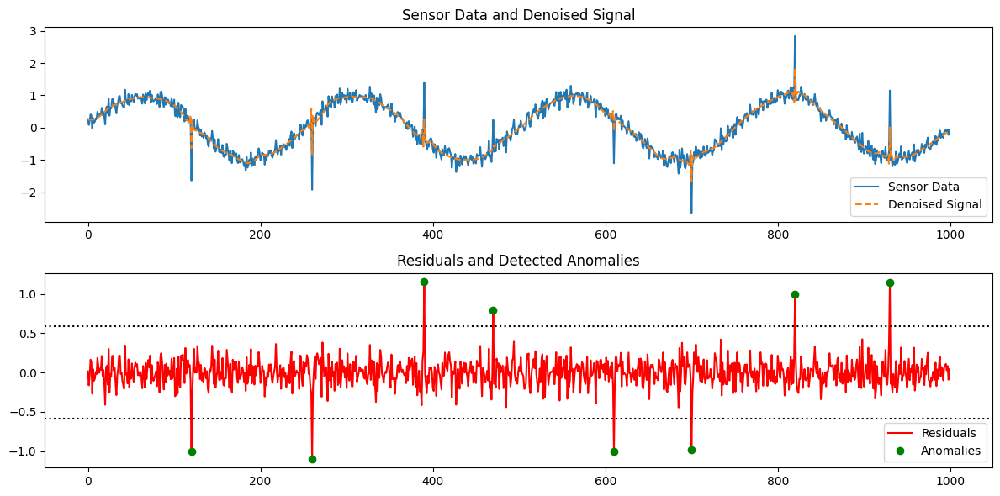

In [6]:
import pywt

np.random.seed(0)
n = 1000
t = np.arange(n)
normal = np.sin(2 * np.pi * t / 250)                    # normal machine behaviour (slow wave)
data = normal + np.random.normal(0, 0.15, n)             # + small sensor noise

true_anom = np.array([120, 260, 390, 470, 610, 700, 820, 930])      # injected faults (spikes)
data[true_anom] += np.random.choice([-1, 1], len(true_anom)) * np.random.uniform(1.2, 2.0, len(true_anom))

# 1) wavelet decomposition (Daubechies-4, 4 levels): [approximation, detail4, detail3, detail2, detail1]
coeffs = pywt.wavedec(data, 'db4', level=4)

# 2) noise level estimated from the finest detail coefficients, universal threshold
sigma = np.median(np.abs(coeffs[-1])) / 0.6745
thr = sigma * np.sqrt(2 * np.log(n))
coeffs[1:] = [pywt.threshold(c, thr, mode='soft') for c in coeffs[1:]]   # shrink small details to 0

# 3) reconstruct the denoised signal
denoised = pywt.waverec(coeffs, 'db4')[:n]

# 4) residuals -> anomalies when |residual| > 4 * robust std
residual = data - denoised
limit = 4 * np.median(np.abs(residual)) / 0.6745
anomalies = np.where(np.abs(residual) > limit)[0]

print('wavelet threshold =', round(thr, 3), '| residual limit =', round(limit, 3))
print('injected faults :', true_anom.tolist())
print('detected        :', anomalies.tolist())
hit = [a for a in true_anom if np.any(np.abs(anomalies - a) <= 2)]
print(f'found {len(hit)}/{len(true_anom)} injected faults, extra detections: {len(anomalies) - len(hit)}')

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(data, label='Sensor Data'); plt.plot(denoised, '--', label='Denoised Signal')
plt.title('Sensor Data and Denoised Signal'); plt.legend(loc='lower right')
plt.subplot(2, 1, 2)
plt.plot(residual, 'r', label='Residuals')
plt.plot(anomalies, residual[anomalies], 'go', label='Anomalies')
plt.axhline(limit, color='k', ls=':'); plt.axhline(-limit, color='k', ls=':')
plt.title('Residuals and Detected Anomalies'); plt.legend(loc='lower right')
plt.tight_layout(); plt.savefig('Output/task3_result.png', dpi=110); plt.show()

**Result:** 8 faults were injected in the sample data and the wavelet method detected **8 / 8 with 0 false alarms**.

**How it works:** `db4` wavelet decomposition (4 levels) splits the data into a slow trend (approximation) and fast details. Small detail coefficients are noise, so they are soft-thresholded to 0 (universal threshold 0.578); reconstruction gives the clean *denoised* signal. A fault is a sudden spike which the smooth signal does not contain, so the **residual = data − denoised** is large there. A robust limit (4 × robust std ≈ 0.59) marks the anomalies (green dots).

## Task 4 – Object recognition in a video (SIFT)
Reference image = the *box* (`box.png`). The test video is created from a photo of the box in a scene (`box_in_scene.png`): frame by frame the scene is **scaled, rotated and partly covered** by a black patch (occlusion). SIFT matches the reference with every frame, RANSAC computes a homography and a bounding box is drawn.

frames: 60 | frames where object was recognised: 49
inliers per frame: [68, 86, 86, 79, 83, 88, 78, 79, 82, 78, 87, 86, 84, 91, 80, 80, 77, 85, 76, 73, 74, 70, 74, 74, 66, 62, 70, 72, 68, 62, 75, 62, 61, 59, 53, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 64, 51, 49, 57, 54, 55, 49, 55, 49, 52, 48, 51, 49, 46]


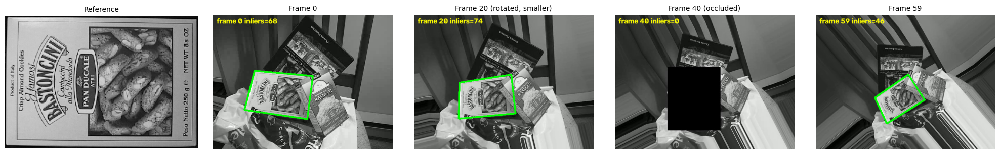

In [7]:
ref = read('box.png')
scene0 = read('box_in_scene.png')
H0, W0 = scene0.shape[:2]

# 1) create the test video (60 frames): scale 1.0 -> 0.7, rotation 0 -> 40 deg, occluder in frames 35-45
writer = cv2.VideoWriter('Output/task4_input.mp4', cv2.VideoWriter_fourcc(*'mp4v'), 15, (W0, H0))
for i in range(60):
    p = i / 59
    M = cv2.getRotationMatrix2D((W0 / 2, H0 / 2), 40 * p, 1.0 - 0.3 * p)
    frame = cv2.warpAffine(scene0, M, (W0, H0), borderMode=cv2.BORDER_REPLICATE)
    if 35 <= i <= 45:
        cv2.rectangle(frame, (150, 150), (300, 330), (0, 0, 0), -1)      # occlusion
    writer.write(frame)
writer.release()

# 2) recognise the object in every frame
k_ref, d_ref = sift.detectAndCompute(cv2.cvtColor(ref, cv2.COLOR_BGR2GRAY), None)
bf = cv2.BFMatcher()
cap = cv2.VideoCapture('Output/task4_input.mp4')
out = cv2.VideoWriter('Output/task4_output.mp4', cv2.VideoWriter_fourcc(*'mp4v'), 15, (W0, H0))
shown, frame_no, stats = [], 0, []
while True:
    ok, frame = cap.read()
    if not ok: break
    k, d = sift.detectAndCompute(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY), None)
    good = [m for m, n in bf.knnMatch(d_ref, d, k=2) if m.distance < 0.7 * n.distance]
    inliers = 0
    if len(good) >= 10:
        src = np.float32([k_ref[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst = np.float32([k[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
        H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
        if H is not None:
            inliers = int(mask.sum())
            if inliers >= 10:
                rh, rw = ref.shape[:2]
                box = cv2.perspectiveTransform(np.float32([[0, 0], [rw, 0], [rw, rh], [0, rh]]).reshape(-1, 1, 2), H)
                cv2.polylines(frame, [np.int32(box)], True, (0, 255, 0), 3)
    cv2.putText(frame, f'frame {frame_no} inliers={inliers}', (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    out.write(frame); stats.append(inliers)
    if frame_no in (0, 20, 40, 59): shown.append(frame.copy())
    frame_no += 1
cap.release(); out.release()
print('frames:', frame_no, '| frames where object was recognised:', sum(s >= 10 for s in stats))
print('inliers per frame:', stats)
show([ref] + shown, ['Reference', 'Frame 0', 'Frame 20 (rotated, smaller)', 'Frame 40 (occluded)', 'Frame 59'],
     'task4_result.png', cols=5, size=4)

**Result:** the box was recognised in **49 of 60 frames** with 46–91 RANSAC inliers, while the video scales it down (1.0 → 0.7) and rotates it up to 40°. The 11 frames in which a black patch hides most of the scene (frames 35–45) gave no detection (the box is hidden), and recognition came back as soon as the occluder disappeared (frame 46: 64 inliers).

SIFT features are scale and rotation invariant, so the bounding box follows the object. Partial occlusion is tolerated as long as ≥ 10 good matches remain. The input and output videos are saved as `Output/task4_input.mp4` and `Output/task4_output.mp4`.

## Task 5 – Panorama stitching with SIFT
For every pair of neighbouring images: SIFT keypoints → matches (ratio test) → homography (RANSAC) → warp one image into the plane of the other → paste.

stitch image 1 + 2
  matches = 229, inliers = 220
stitch (1+2) + 3


  matches = 182, inliers = 158


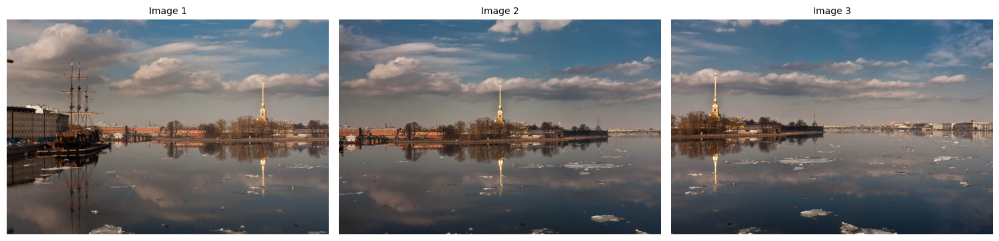

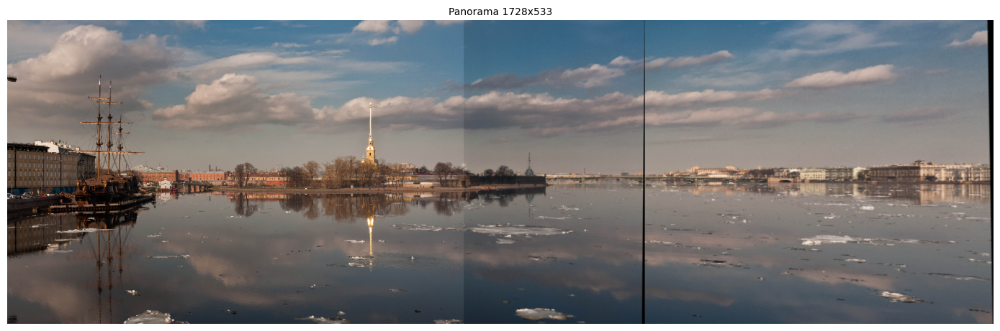

In [8]:
imgs = [read(f, 800) for f in ['boat1.jpg', 'boat2.jpg', 'boat3.jpg']]      # left -> right order

def stitch(left, right):
    k1, d1 = sift.detectAndCompute(cv2.cvtColor(left, cv2.COLOR_BGR2GRAY), None)
    k2, d2 = sift.detectAndCompute(cv2.cvtColor(right, cv2.COLOR_BGR2GRAY), None)
    good = [m for m, n in cv2.BFMatcher().knnMatch(d2, d1, k=2) if m.distance < 0.7 * n.distance]
    src = np.float32([k2[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)    # points in the right image
    dst = np.float32([k1[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)    # same points in the left image
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 4.0)
    print(f'  matches = {len(good)}, inliers = {int(mask.sum())}')
    canvas = cv2.warpPerspective(right, H, (left.shape[1] + right.shape[1], left.shape[0]))   # right image into left's plane
    canvas[0:left.shape[0], 0:left.shape[1]] = left                                              # paste left image
    # remove the black area on the right
    cols = np.where(canvas.sum(axis=(0, 2)) > 0)[0]
    return canvas[:, :cols.max() + 1]

print('stitch image 1 + 2'); pano = stitch(imgs[0], imgs[1])
print('stitch (1+2) + 3');    pano = stitch(pano, imgs[2])
cv2.imwrite('Output/task5_panorama.jpg', pano)
show(imgs, ['Image 1', 'Image 2', 'Image 3'], size=5)
show([pano], [f'Panorama {pano.shape[1]}x{pano.shape[0]}'], 'task5_result.png', size=14)

**Result:** 3 overlapping photos were stitched into one panorama of 1728 × 533 pixels (image 1+2: 220 RANSAC inliers, then +3: 158 inliers), saved as `Output/task5_panorama.jpg`.

Steps: SIFT keypoints → ratio-test matches → RANSAC homography → `warpPerspective` of the right image onto the left → paste. The structures (spire, ships, reflections) line up. Limitation: this simple version just pastes the images, so a slight **brightness seam** and a thin black line at the joint (different exposure / warped border) are visible – blending (feathering) or `cv2.Stitcher` would hide them.

## Task 6 – Lane detection (Hough Line Transform)
Pipeline: grayscale → blur → Canny → **region of interest** (trapezoid in front of the car) → Hough lines → split into left / right lane by slope → average each side → draw.

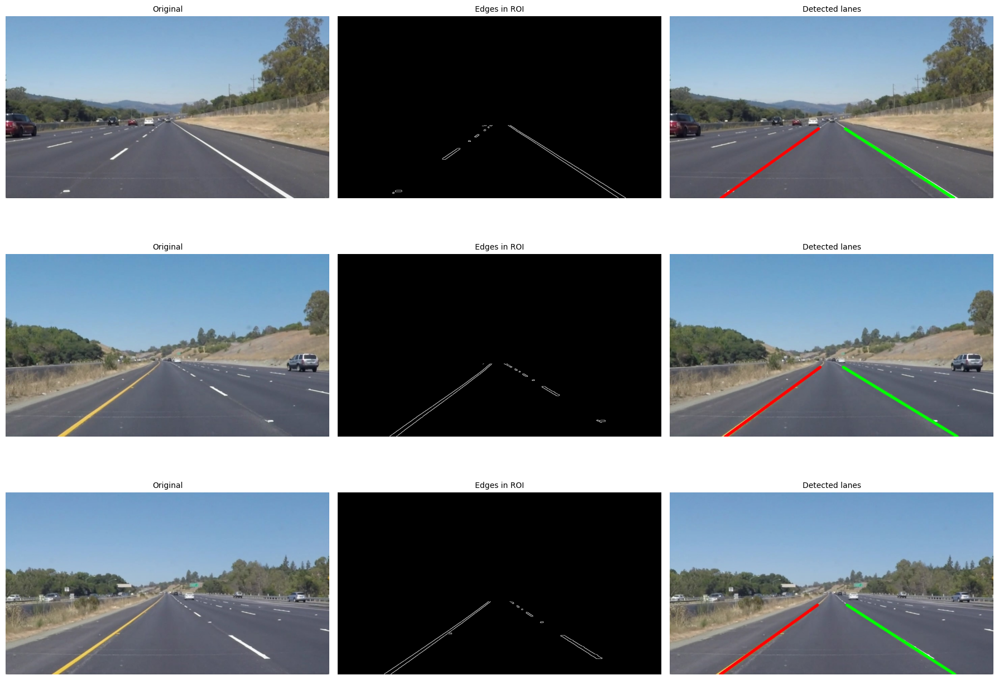

In [9]:
def detect_lanes(img):
    h, w = img.shape[:2]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(cv2.GaussianBlur(gray, (5, 5), 0), 50, 150)

    # keep only the road area (trapezoid) - everything else is black
    roi = np.zeros_like(edges)
    poly = np.array([[(int(0.08 * w), h), (int(0.45 * w), int(0.6 * h)), (int(0.55 * w), int(0.6 * h)), (int(0.95 * w), h)]])
    cv2.fillPoly(roi, poly, 255)
    edges_roi = cv2.bitwise_and(edges, roi)

    lines = cv2.HoughLinesP(edges_roi, 1, np.pi / 180, threshold=30, minLineLength=40, maxLineGap=100)

    left, right = [], []
    for x1, y1, x2, y2 in lines.reshape(-1, 4):
        if x2 == x1: continue
        slope = (y2 - y1) / (x2 - x1)
        intercept = y1 - slope * x1
        if slope < -0.4:   left.append((slope, intercept))      # image y goes down, so left lane has negative slope
        elif slope > 0.4:  right.append((slope, intercept))

    result = img.copy()
    for side, color in ((left, (0, 0, 255)), (right, (0, 255, 0))):
        if side:
            s, b = np.mean(side, axis=0)                          # average line of this lane
            y1, y2 = h, int(0.62 * h)
            cv2.line(result, (int((y1 - b) / s), y1), (int((y2 - b) / s), y2), color, 8)
    return edges_roi, result

rows = []
for name in ['road1.jpg', 'road2.jpg', 'road3.jpg']:
    im = read(name)
    e, res = detect_lanes(im)
    rows += [im, e, res]
show(rows, ['Original', 'Edges in ROI', 'Detected lanes'] * 3, 'task6_result.png', cols=3, size=6)

**Result:** left (red) and right (green) lane lines are found on all three road images.

Steps: grayscale → blur → Canny → ROI trapezoid (removes trees, sky and cars) → `HoughLinesP` → left lines have negative slope and right lines positive slope (image y goes downward) → the lines of each side are averaged into one lane line and extended to the bottom. The ROI is the most important step – without it, the many edges of the scenery create wrong lines. Limitations: only straight lanes (curved lanes would need a polynomial fit) and a fixed camera position for the ROI.

## Task 7 – Coins detection and counting (Hough Circle Transform)
`cv2.HoughCircles` finds circles. Main parameters: `dp` (accumulator resolution), `minDist` (min distance between circle centres), `param1` (Canny high threshold), `param2` (accumulator threshold – smaller = more circles, also false ones), `minRadius / maxRadius`.

Coins image    -> circles counted: 24
Smarties image -> circles counted: 16


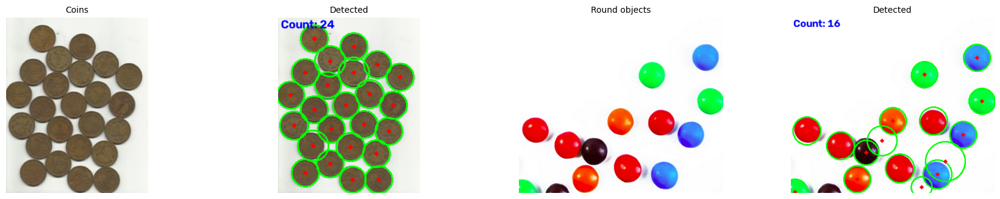

In [10]:
def count_coins(name, param2, minR, maxR, minDist):
    img = read(name)
    gray = cv2.medianBlur(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), 5)         # blur reduces false circles
    circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, dp=1, minDist=minDist,
                               param1=50, param2=param2, minRadius=minR, maxRadius=maxR)
    out = img.copy()
    circles = np.uint16(np.around(circles.reshape(-1, 3))) if circles is not None else []
    for i, (x, y, r) in enumerate(circles, 1):
        cv2.circle(out, (x, y), r, (0, 255, 0), 2)           # circle outline
        cv2.circle(out, (x, y), 2, (0, 0, 255), 3)           # centre
    cv2.putText(out, f'Count: {len(circles)}', (5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
    return img, out, len(circles)

# image 1: coins (about 24 coins),  image 2: round sweets with different sizes
img1, out1, n1 = count_coins('coins1.jpg', param2=18, minR=15, maxR=35, minDist=28)
img2, out2, n2 = count_coins('smarties.png', param2=12, minR=20, maxR=45, minDist=30)
print('Coins image    -> circles counted:', n1)
print('Smarties image -> circles counted:', n2)
show([img1, out1, img2, out2], ['Coins', 'Detected', 'Round objects', 'Detected'], 'task7_result.png', cols=4, size=4.5)

In [11]:
# Effect of param2 (accumulator threshold) on the coins image
for p2 in [8, 12, 18, 25, 35, 50]:
    print(f'param2 = {p2:2} -> circles = {count_coins("coins1.jpg", p2, 15, 35, 28)[2]}')

param2 =  8 -> circles = 26
param2 = 12 -> circles = 24
param2 = 18 -> circles = 24
param2 = 25 -> circles = 23
param2 = 35 -> circles = 15
param2 = 50 -> circles = 3


**Result:** 24 coins were counted in the coins image (correct: 24, including touching coins) and 16 round sweets in the second image (correct).

**Effect of `param2`:** small value (8) = too many circles (26, false ones); 12–25 gives 24–23 (correct); large value (35, 50) = only circles with very strong edges are accepted → many coins missed (15, 3). `minRadius / maxRadius` must match the coin size, `minDist` stops multiple circles on one coin, and median blur removes the texture of the coins that would create false circles.

## Task 8 – Smart security system (boundary detection in a video)
A **security zone** (red rectangle) is defined in the video. For every frame: background subtraction (MOG2) → clean mask → **contours = object boundaries** → if a moving object's boundary enters the zone, the **ALARM** is raised. Video: `vtest.avi` (OpenCV sample, people walking).

frames processed: 795 | frames with ALARM: 129
first alarm at frame: 531


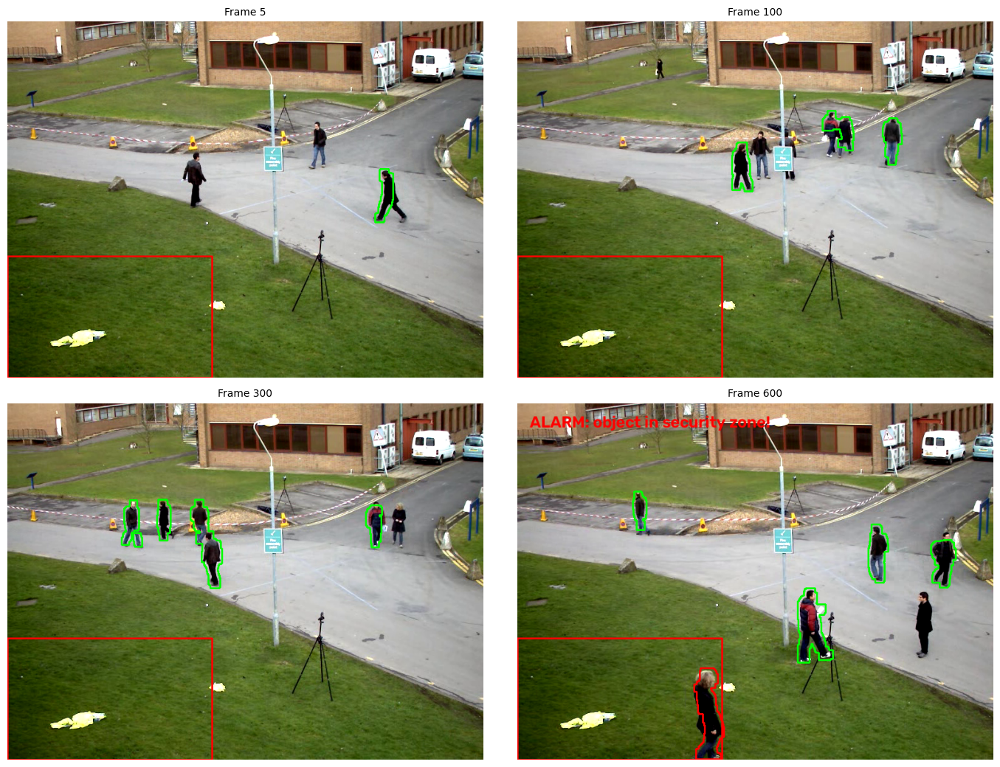

In [12]:
ZONE = (0, 380, 330, 576)          # security zone (x1, y1, x2, y2)

cap = cv2.VideoCapture('Data/vtest.avi')
W, H = int(cap.get(3)), int(cap.get(4))
out = cv2.VideoWriter('Output/task8_output.mp4', cv2.VideoWriter_fourcc(*'mp4v'), 10, (W, H))
bg = cv2.createBackgroundSubtractorMOG2(history=100, varThreshold=50, detectShadows=True)
kernel = np.ones((5, 5), np.uint8)

alarm_frames, shots, frame_no = [], [], 0
while True:
    ok, frame = cap.read()
    if not ok: break
    mask = bg.apply(frame)
    mask = cv2.threshold(mask, 200, 255, cv2.THRESH_BINARY)[1]          # drop shadows (value 127)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)               # remove small noise
    mask = cv2.dilate(mask, kernel, iterations=2)                       # fill holes in objects

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)   # object boundaries
    alarm = False
    for c in contours:
        if cv2.contourArea(c) < 800: continue                           # ignore tiny objects
        x, y, w, h = cv2.boundingRect(c)
        inside = not (x + w < ZONE[0] or x > ZONE[2] or y + h < ZONE[1] or y > ZONE[3])   # boxes overlap the zone?
        color = (0, 0, 255) if inside else (0, 255, 0)
        cv2.drawContours(frame, [c], -1, color, 2)
        if inside and frame_no > 30: alarm = True      # first frames = background learning
    cv2.rectangle(frame, ZONE[:2], ZONE[2:], (0, 0, 255), 2)
    if alarm:
        cv2.putText(frame, 'ALARM: object in security zone!', (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 3)
        alarm_frames.append(frame_no)
    out.write(frame)
    if frame_no in (5, 100, 300, 600): shots.append(frame.copy())
    frame_no += 1
cap.release(); out.release()
print('frames processed:', frame_no, '| frames with ALARM:', len(alarm_frames))
print('first alarm at frame:', alarm_frames[0] if alarm_frames else None)
show(shots, ['Frame 5', 'Frame 100', 'Frame 300', 'Frame 600'], 'task8_result.png', cols=2, size=7)

**Result:** MOG2 background subtraction detects the walking people, their boundary (contour) is drawn green outside the zone and **red inside the zone**. The security zone is the red rectangle in the bottom-left lawn. An alarm is raised only in frames where a person's boundary enters it (129 of 795 frames, first at frame 531). The first 30 frames are ignored while the background model learns.

Limitations: it detects *any moving object* (not only unauthorised ones), shadows / lighting changes can create false contours (shadow detection is switched on and removed), and a stationary object eventually becomes part of the background. The annotated video is saved as `Output/task8_output.mp4`.